# Review Sentiment Analysis Project

Full notebook version for the assignment.

This notebook:
- loads a Kaggle review dataset
- cleans and prepares text
- performs EDA
- trains and compares 3 models
- identifies reviews that require a response
- saves outputs for the final report

Recommended dataset:
`data/IMDB Dataset.csv`


In [1]:

import json
import re
import string
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
DATA_PATH = Path("data/IMDB Dataset.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Helper functions


In [2]:

def clean_text(text: str) -> str:
    """Normalize text for ML."""
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)            # remove HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # remove URLs
    text = text.replace("\n", " ").replace("\r", " ")
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)             # remove digits
    text = re.sub(r"\s+", " ", text).strip()    # normalize spaces
    return text


def prepare_dataframe(df: pd.DataFrame, text_column: str = "review", label_column: str = "sentiment") -> pd.DataFrame:
    """Clean dataset and create engineered features."""
    df = df[[text_column, label_column]].copy()
    df = df.dropna(subset=[text_column, label_column])

    df[label_column] = df[label_column].astype(str).str.strip().str.lower()

    label_map = {
        "positive": 1,
        "negative": 0,
        "pos": 1,
        "neg": 0,
        "1": 1,
        "0": 0,
    }

    df = df[df[label_column].isin(label_map.keys())].copy()
    df["label"] = df[label_column].map(label_map)

    df["clean_text"] = df[text_column].astype(str).apply(clean_text)
    df = df[df["clean_text"].str.len() > 0].copy()

    df["char_count"] = df["clean_text"].str.len()
    df["word_count"] = df["clean_text"].str.split().str.len()

    return df.reset_index(drop=True)


def save_dataset_overview(df: pd.DataFrame, out_dir: Path) -> None:
    """Save EDA outputs."""
    summary = {
        "rows": int(len(df)),
        "avg_word_count": float(df["word_count"].mean()),
        "median_word_count": float(df["word_count"].median()),
        "positive_ratio": float(df["label"].mean()),
        "negative_ratio": float(1 - df["label"].mean()),
    }

    with open(out_dir / "dataset_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    plt.figure(figsize=(6, 4))
    df["label"].value_counts().sort_index().plot(kind="bar")
    plt.xticks([0, 1], ["Negative (0)", "Positive (1)"], rotation=0)
    plt.title("Label Distribution")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(out_dir / "label_distribution.png", dpi=150)
    plt.show()
    plt.close()

    plt.figure(figsize=(8, 4))
    df["word_count"].plot(kind="hist", bins=40)
    plt.title("Review Length Distribution (Word Count)")
    plt.xlabel("Word count")
    plt.tight_layout()
    plt.savefig(out_dir / "review_length_distribution.png", dpi=150)
    plt.show()
    plt.close()


In [3]:

def build_models(max_features: int = 20000, min_df: int = 3, max_df: float = 0.95) -> dict:
    """Build 3 pipelines with TF-IDF + classifier."""
    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        max_features=max_features,
        min_df=min_df,
        max_df=max_df,
        sublinear_tf=True,
    )

    return {
        "logistic_regression": Pipeline(
            [
                ("tfidf", clone(vectorizer)),
                ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver="liblinear")),
            ]
        ),
        "random_forest": Pipeline(
            [
                ("tfidf", clone(vectorizer)),
                ("clf", RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1)),
            ]
        ),
        "mlp": Pipeline(
            [
                ("tfidf", clone(vectorizer)),
                ("clf", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20, early_stopping=True, random_state=RANDOM_STATE)),
            ]
        ),
    }


def build_param_grids() -> dict:
    """Hyperparameter grids for model tuning."""
    return {
        "logistic_regression": {
            "tfidf__max_features": [10000, 20000],
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "clf__C": [0.5, 1.0, 2.0],
        },
        "random_forest": {
            "tfidf__max_features": [10000],
            "clf__n_estimators": [150, 250],
            "clf__max_depth": [None, 30],
        },
        "mlp": {
            "tfidf__max_features": [10000],
            "clf__hidden_layer_sizes": [(100,), (128, 64)],
            "clf__alpha": [0.0001, 0.001],
        },
    }


def evaluate_model(model: Pipeline, x_test: pd.Series, y_test: pd.Series) -> tuple:
    """Return metrics and predictions."""
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }

    if y_prob is not None:
        metrics["roc_auc"] = roc_auc_score(y_test, y_prob)

    metrics["classification_report"] = classification_report(
        y_test,
        y_pred,
        target_names=["negative", "positive"],
        output_dict=True,
    )
    return metrics, y_pred


def save_confusion_matrix(y_true: pd.Series, y_pred: np.ndarray, path: Path, title: str) -> None:
    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_pred))
    disp.plot(values_format="d")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()


def detect_response_needed(df_reviews: pd.DataFrame, model: Pipeline) -> pd.DataFrame:
    """Identify reviews that likely require a response."""
    escalation_keywords = {
        "refund", "scam", "fraud", "broken", "terrible", "worst",
        "never again", "complaint", "angry", "disappointed", "late",
        "damaged", "cancel", "lawsuit", "bad service", "poor quality", "not working",
    }

    result = df_reviews.copy()

    if hasattr(model, "predict_proba"):
        positive_proba = model.predict_proba(result["clean_text"])[:, 1]
        negative_proba = 1 - positive_proba
    else:
        predictions = model.predict(result["clean_text"])
        negative_proba = np.where(predictions == 0, 1.0, 0.0)

    result["negative_probability"] = negative_proba
    result["predicted_label"] = (result["negative_probability"] < 0.5).astype(int)

    def keyword_flag(text: str) -> int:
        return int(any(keyword in text.lower() for keyword in escalation_keywords))

    result["has_escalation_keyword"] = result["clean_text"].apply(keyword_flag)

    result["response_needed"] = (
        (result["negative_probability"] >= 0.85)
        | ((result["negative_probability"] >= 0.70) & (result["word_count"] >= 25))
        | (result["has_escalation_keyword"] == 1)
    ).astype(int)

    result["response_reason"] = np.select(
        [
            result["has_escalation_keyword"] == 1,
            result["negative_probability"] >= 0.85,
            (result["negative_probability"] >= 0.70) & (result["word_count"] >= 25),
        ],
        [
            "keyword-based escalation",
            "very negative sentiment",
            "negative and detailed review",
        ],
        default="no response needed",
    )

    return result.sort_values(
        by=["response_needed", "negative_probability", "word_count"],
        ascending=[False, False, False],
    ).reset_index(drop=True)


## 2. Load and prepare data


In [4]:

df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()


Raw shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:

df = prepare_dataframe(df_raw, text_column="review", label_column="sentiment")
print("Prepared shape:", df.shape)
df.head()


Prepared shape: (50000, 6)


,review,sentiment,label,clean_text,char_count,word_count
0,One of the other reviewers has mentioned that ...,positive,1,one of the other reviewers has mentioned that ...,1666,303
1,A wonderful little production. <br /><br />The...,positive,1,a wonderful little production the filming tech...,936,156
2,I thought this was a wonderful way to spend ti...,positive,1,i thought this was a wonderful way to spend ti...,874,163
3,Basically there's a family where a little boy ...,negative,0,basically theres a family where a little boy j...,683,130
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,petter matteis love in the time of money is a ...,1240,225


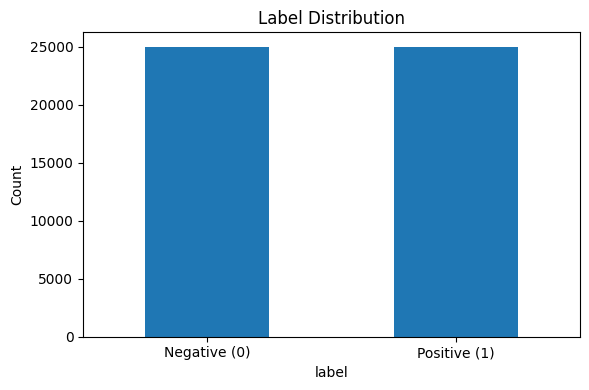

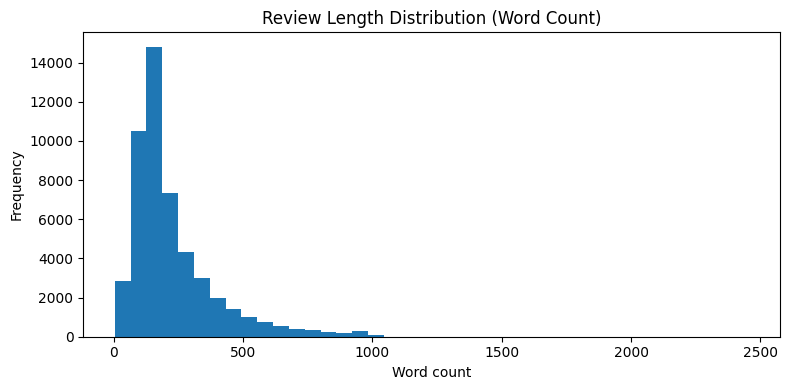

In [6]:

save_dataset_overview(df, OUTPUT_DIR)


In [7]:

print(df["label"].value_counts())
print(df[["word_count", "char_count"]].describe())


label
1    25000
0    25000
Name: count, dtype: int64
         word_count    char_count
count  50000.000000  50000.000000
mean     226.927440   1241.171660
std      168.277644    939.428159
min        4.000000     30.000000
25%      124.000000    665.000000
50%      170.000000    920.000000
75%      275.000000   1505.000000
max     2452.000000  13273.000000


## 3. Train/test split

Important fix:
we preserve original indices so that `word_count` and `char_count`
can be copied into `test_df` later. Without this, `detect_response_needed()`
fails with `KeyError: 'word_count'`.


In [8]:

x = df["clean_text"]
y = df["label"]

x_train, x_test, y_train, y_test, idx_train, idx_test = train_test_split(
    x,
    y,
    df.index,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train size:", len(x_train))
print("Test size:", len(x_test))


Train size: 40000
Test size: 10000


## 4. Train and compare 3 models



Training model: logistic_regression
Fitting 3 folds for each of 12 candidates, totalling 36 fits


<Figure size 500x400 with 0 Axes>

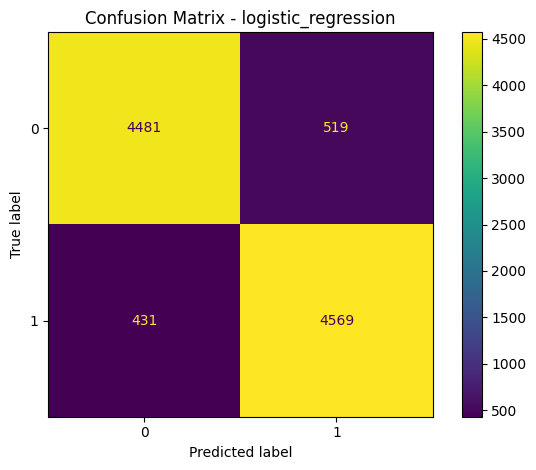


Training model: random_forest
Fitting 3 folds for each of 4 candidates, totalling 12 fits


<Figure size 500x400 with 0 Axes>

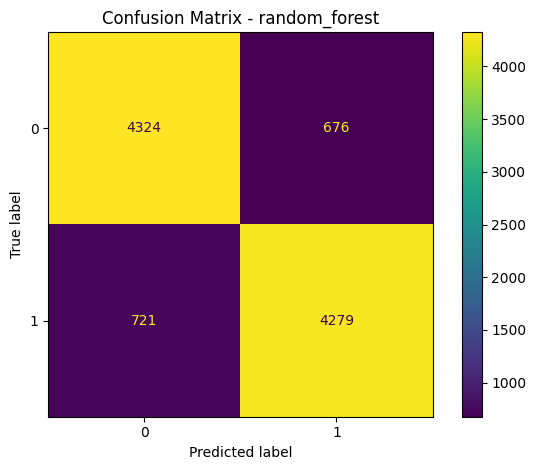


Training model: mlp
Fitting 3 folds for each of 4 candidates, totalling 12 fits


<Figure size 500x400 with 0 Axes>

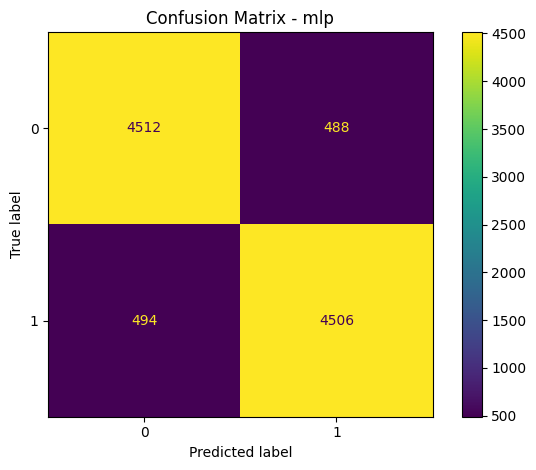

,model,best_params,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,"{'clf__C': 2.0, 'tfidf__max_features': 20000, ...",0.9050,0.897995,0.9138,0.905829,0.965650
1,mlp,"{'clf__alpha': 0.0001, 'clf__hidden_layer_size...",0.9018,0.902283,0.9012,0.901741,0.964112
2,random_forest,"{'clf__max_depth': None, 'clf__n_estimators': ...",0.8603,0.863572,0.8558,0.859669,0.936017


In [9]:

models = build_models()
param_grids = build_param_grids()

rows = []
trained_models = {}

for name, pipeline in models.items():
    print(f"\nTraining model: {name}")

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        scoring="f1",
        cv=3,
        n_jobs=-1,
        verbose=1,
    )
    search.fit(x_train, y_train)

    best_model = search.best_estimator_
    trained_models[name] = best_model

    metrics, y_pred = evaluate_model(best_model, x_test, y_test)

    save_confusion_matrix(
        y_true=y_test,
        y_pred=y_pred,
        path=OUTPUT_DIR / f"confusion_matrix_{name}.png",
        title=f"Confusion Matrix - {name}",
    )

    with open(OUTPUT_DIR / f"classification_report_{name}.json", "w", encoding="utf-8") as f:
        json.dump(metrics["classification_report"], f, indent=2)

    rows.append({
        "model": name,
        "best_params": str(search.best_params_),
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics.get("roc_auc", np.nan),
    })

comparison_df = pd.DataFrame(rows).sort_values(by="f1", ascending=False).reset_index(drop=True)
comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

comparison_df


## 5. Select best model


In [10]:

best_model_name = comparison_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
joblib.dump(best_model, OUTPUT_DIR / "best_model.joblib")


Best model: logistic_regression


['outputs\\best_model.joblib']

## 6. Detect reviews that need a response

This is the fixed part.
`test_df` includes `word_count` and `char_count`.


In [11]:

test_df = df.loc[idx_test, ["clean_text", "word_count", "char_count"]].copy().reset_index(drop=True)
test_df["true_label"] = y_test.reset_index(drop=True)

test_df.head()


,clean_text,word_count,char_count,true_label
0,yes mtv there really is a way to market daria ...,144,740,0
1,the story of the bride fair is an amusing and ...,125,758,0
2,a team varied between scully and mulder two ot...,188,1030,1
3,this was a popular movie probably because of t...,167,913,0
4,this movie made me so angry here i am thinking...,125,659,0


In [12]:

flagged_reviews = detect_response_needed(test_df, best_model)
flagged_reviews.to_csv(OUTPUT_DIR / "flagged_reviews.csv", index=False)

flagged_reviews.head(20)


,clean_text,word_count,char_count,true_label,negative_probability,predicted_label,has_escalation_keyword,response_needed,response_reason
0,i knew it was going to be awful but not this a...,391,2097,0,0.999969,0,1,1,keyword-based escalation
1,the horrific production doesnt qualify as a fi...,238,1294,0,0.999958,0,1,1,keyword-based escalation
2,terrible movie nuff said these lines are just ...,152,778,0,0.999937,0,1,1,keyword-based escalation
3,this film is the worst film i have ever seen t...,69,368,0,0.999926,0,1,1,keyword-based escalation
4,i tried as hard as i could to sit all the way ...,96,513,0,0.999923,0,0,1,very negative sentiment
5,this movie is pathetic in every way possible b...,68,380,0,0.999912,0,1,1,keyword-based escalation
6,honestly awful film bad editing awful lighting...,159,863,0,0.999909,0,1,1,keyword-based escalation
7,tries to be funny and fails miserably the anim...,48,236,0,0.999897,0,1,1,keyword-based escalation
8,komodo vs cobra starts as one planet environme...,511,2885,0,0.999895,0,1,1,keyword-based escalation
9,one of the worst films ever not funny poor tv ...,119,633,0,0.999888,0,1,1,keyword-based escalation


## 7. Save run summary


In [13]:

with open(OUTPUT_DIR / "run_summary.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_model": best_model_name,
            "models_compared": comparison_df["model"].tolist(),
            "output_dir": str(OUTPUT_DIR.resolve()),
        },
        f,
        indent=2,
    )

print("All outputs saved to:", OUTPUT_DIR.resolve())


All outputs saved to: C:\Users\matas\Desktop\Elektroninio verslo sistemos\LD1\outputs


## 8. Optional analysis cell

Use this for your report discussion.


In [14]:

print("Model comparison:")
display(comparison_df)

print("\nResponse-needed distribution:")
display(flagged_reviews["response_needed"].value_counts())

print("\nTop flagged reviews:")
display(flagged_reviews[["clean_text", "negative_probability", "word_count", "response_reason"]].head(10))


Model comparison:


,model,best_params,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,"{'clf__C': 2.0, 'tfidf__max_features': 20000, ...",0.9050,0.897995,0.9138,0.905829,0.965650
1,mlp,"{'clf__alpha': 0.0001, 'clf__hidden_layer_size...",0.9018,0.902283,0.9012,0.901741,0.964112
2,random_forest,"{'clf__max_depth': None, 'clf__n_estimators': ...",0.8603,0.863572,0.8558,0.859669,0.936017



Response-needed distribution:


response_needed
1    5625
0    4375
Name: count, dtype: int64


Top flagged reviews:


,clean_text,negative_probability,word_count,response_reason
0,i knew it was going to be awful but not this a...,0.999969,391,keyword-based escalation
1,the horrific production doesnt qualify as a fi...,0.999958,238,keyword-based escalation
2,terrible movie nuff said these lines are just ...,0.999937,152,keyword-based escalation
3,this film is the worst film i have ever seen t...,0.999926,69,keyword-based escalation
4,i tried as hard as i could to sit all the way ...,0.999923,96,very negative sentiment
5,this movie is pathetic in every way possible b...,0.999912,68,keyword-based escalation
6,honestly awful film bad editing awful lighting...,0.999909,159,keyword-based escalation
7,tries to be funny and fails miserably the anim...,0.999897,48,keyword-based escalation
8,komodo vs cobra starts as one planet environme...,0.999895,511,keyword-based escalation
9,one of the worst films ever not funny poor tv ...,0.999888,119,keyword-based escalation
